# Homework 2: Probability Models

BEE 4850/5850

**Name**: Fenya Bartram

**ID**: fdb34

> **Due Date**
>
> Friday, 2/21/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit a sea-level rise model using normal
    residuals and to assess the validity of that assumption.
-   Problem 2 asks you to model the time series of hourly
    weather-related variability at a tide gauge using an autoregressive
    model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 (only required for students in BEE 5850) asks you to look
    at the impact of the gender of hurricane names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  
import scipy
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy.optimize import minimize
import math
from scipy.optimize import Bounds
from scipy.stats import poisson
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import pacf




## Problems

### Scoring

-   Problem 1 is worth 7 points.
-   Problem 2 is worth 6 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data.
-   Fit the model under the assumption of Gaussian i.i.d. residuals
    (include both an uncertain model error term and the standard
    deviation of the observations in the probability model
    specification) by maximizing the likelihood. Report the parameter
    estimates. Note that you will need another parameter $S_0$ for the
    initial sea level. What can you conclude about the relationship
    between global mean temperature increases and global mean sea level
    rise rates?
-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?

# Solution

I load the datasets and create a model to simulate the sea-level rise using discretization. I minimize the negative of the log likelihood, equivalent to maximizing the log likelihood, in order to fit the model with parameters, including the model error term. I take the residuals as the difference between the observed and simulated values, and plot these on a Q-Q plot to test for normality, and on a partial autocorrelation plot to check for autocorrelation.

In [2]:
# Load data

data_dir = os.path.join("data", "HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv")
gmt_data = pd.read_csv(data_dir, index_col = 'Time')
gmt_data['Anomaly (deg C)'] = gmt_data['Anomaly (deg C)'] - gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()
gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()
data_dir = os.path.join("data", "CSIRO_Recons_gmsl_yr_2015.csv")
gmsa_data = pd.read_csv(data_dir, index_col = 'Time')
# gmsa_data = pd.read_csv(data_dir)
gmsa_data.index = gmsa_data.index-0.5
gmsa_data['GMSL (mm)'] = gmsa_data['GMSL (mm)'] - gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()
gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()
gmt_data = gmt_data.drop(gmt_data.index.difference(gmsa_data.index))
len(gmt_data)

134

In [3]:
Seq = np.zeros(len(gmt_data))
def sim_gmsl(S_0, gmta_data, response_time, a, b):
    Seq = np.zeros(len(gmta_data))
    S = np.zeros(len(gmta_data))
    S[0] = S_0
        
    for i in range(0,len(gmta_data)-1):
        Seq[i] = a*gmta_data.iloc[i] + b
        S[i+1] = S[i] + (Seq[i]-S[i])/response_time
    
    return(S)
        

In [4]:
def gmsl_loglik(params, gmsl_data, gmta_data, gmsl_error):
    S_0, response_time, a, b, σ  = params  # unpack parameter vector
    y = sim_gmsl(S_0, gmta_data, response_time, a, b)
    ll = np.sum(norm.logpdf(gmsl_data, loc=y, scale=np.sqrt(σ**2+gmsl_error**2)))  # compute log-likelihood
    return ll

In [5]:
lb = [-100000.0, 0.0, -100000.0,-100000.0, 0.0]
ub = [100000.0, 100000.0, 100000.0,100000.0, 100000.0]
p0 = [-160, 208.0, 1290.0, 770.0, 0.0]

optim_out = minimize(lambda params: -gmsl_loglik(params, gmsa_data['GMSL (mm)'], gmt_data['Anomaly (deg C)'], gmsa_data['GMSL uncertainty (mm)']), p0, bounds=list(zip(lb, ub)))
p_mle = np.round(optim_out.x)

print(p_mle)

C:\Users\fenya\AppData\Local\Temp\ipykernel_19680\4105603073.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  S[i+1] = S[i] + (Seq[i]-S[i])/response_time
C:\Users\fenya\AppData\Local\Temp\ipykernel_19680\4105603073.py:9: RuntimeWarning: invalid value encountered in scalar add
  S[i+1] = S[i] + (Seq[i]-S[i])/response_time
C:\Users\fenya\AppData\Local\Temp\ipykernel_19680\4105603073.py:9: RuntimeWarning: overflow encountered in scalar divide
  S[i+1] = S[i] + (Seq[i]-S[i])/response_time
C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_continuous_distns.py:365: RuntimeWarning: overflow encountered in square
  return -x**2 / 2.0 - _norm_pdf_logC


[-157.  150.  506.  350.    0.]


In [6]:
sim_out = sim_gmsl(p_mle[0], gmt_data['Anomaly (deg C)'], p_mle[1], p_mle[2], p_mle[3])
sim_out = pd.Series(data = sim_out, index = gmt_data.index)

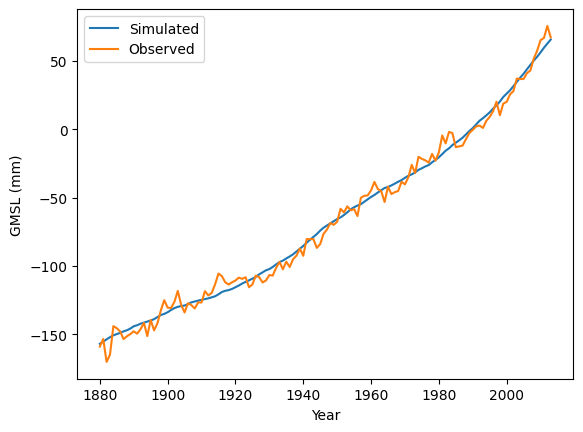

In [7]:
sim_out.plot()
gmsa_data['GMSL (mm)'].plot()
plt.xlabel('Year')
plt.ylabel('GMSL (mm)')
plt.legend(['Simulated', 'Observed'])

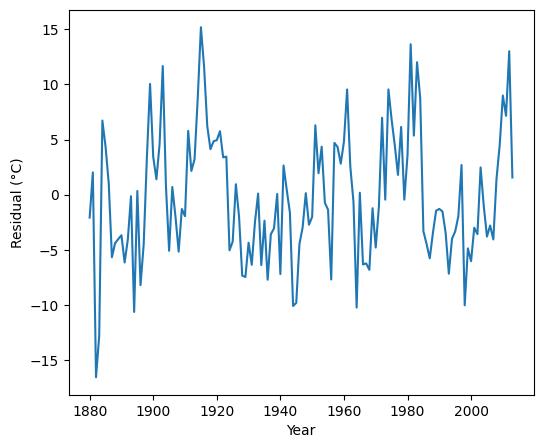

In [8]:
resids_homogauss = gmsa_data['GMSL (mm)'] - sim_out

# Plotting residuals
plt.figure(figsize=(6, 5))
plt.plot(resids_homogauss)
plt.xlabel("Year")
plt.ylabel("Residual (°C)")
plt.show()


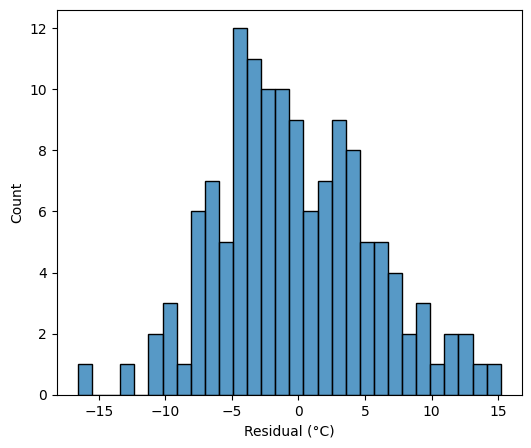

In [9]:
# Histogram of residuals
plt.figure(figsize=(6, 5))
sns.histplot(resids_homogauss, bins=30)
plt.xlabel("Residual (°C)")
plt.ylabel("Count")
plt.show()

<Figure size 600x500 with 0 Axes>

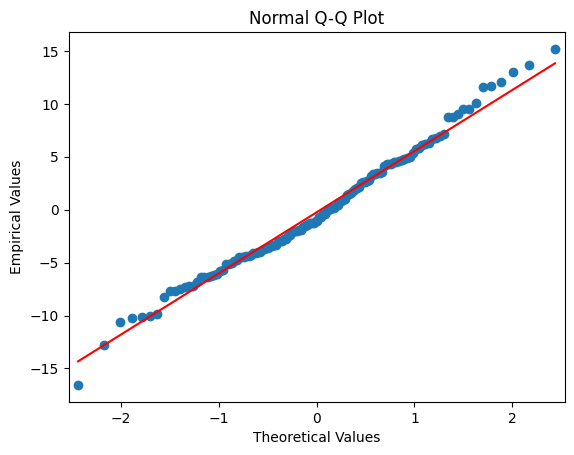

In [10]:
# Q-Q plot
plt.figure(figsize=(6, 5))
qqplot(resids_homogauss, line='s')
plt.title("Normal Q-Q Plot")
plt.xlabel("Theoretical Values")
plt.ylabel("Empirical Values")
plt.show()

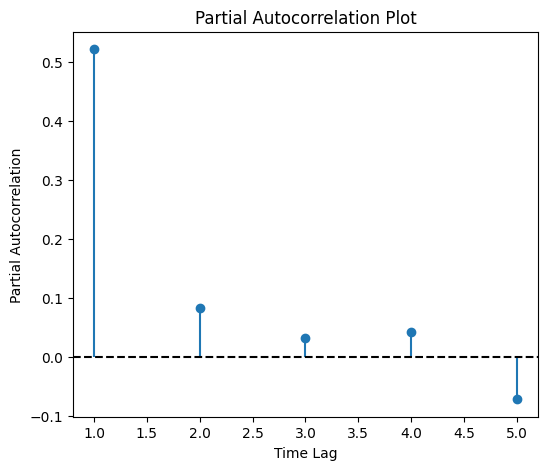

In [11]:
# Partial Autocorrelation
pacf_homogauss = pacf(resids_homogauss, nlags=5)

# Partial Autocorrelation Plot
plt.figure(figsize=(6, 5))
plt.stem(range(1, 6), pacf_homogauss[1:], markerfmt='o', basefmt=" ")
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Partial Autocorrelation")
plt.xlabel("Time Lag")
plt.title("Partial Autocorrelation Plot")
plt.show()

Report the parameter
estimates. Note that you will need another parameter $S_0$ for the
initial sea level. What can you conclude about the relationship
between global mean temperature increases and global mean sea level
rise rates?

Parameter values: 
- $S_0$ initial sea level: -157 mm
-   $\tau$ is the response time of sea level (in yrs): 150 years
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C): 506 
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm): 351

The positive value of $a$ indicates a positive relationship between global mean temperature increases and global mean sea level rise rates, as is expected.

-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?


The Gaussian i.i.d. probability model for the residuals seems reasonable, as the data points generally align with the one-to-one line for the Q-Q plot. However, they do appear to deviate somewhat from normal, particularly for the tails of the distribution. There also appears to be a significant autocorrelation for a time lag of 1, as shown by the partial autocorrelation plot. Thus, modeling the residuals as an AR1 model would likely be more appropriate.

### Problem 2

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

**In this problem**:

-   Load the data file. Take the difference between the observations and
    the sinusoidal predictions to obtain the tide level which could be
    attributed to weather-related variability (since for one year
    sea-level rise and other factors are unlikely to matter). Plot this
    data.
-   Develop an autoregressive (AR) model for the weather-related
    variability in the Norfolk tide gauge. Make sure to include your
    logic or exploratory analysis used in determining the model
    specification.
-   Use your model to simulate 1,000 realizations of hourly tide gauge
    observations by adding simulations from your AR model back to the
    predicted sinusoidal trend. What is the distribution of the maximum
    tide level? How does this compare to the observed value?

# Solution

I create a partial autocorrelation plot to determine which AR model to use. I assume an AR1 model since the partial autocorrelation is very high for a time lag of 1, and much lower for the others. (This is my logic or exploratory analysis used in determining the model specification). I plot an AR1 model using the selected parameters. For 1,000 different realizations, I simulate the variability using the fitted AR1 model, add this back to the sinusoidal trend, and take the maximum of this. I look at the distribution of these maximum values, and compare it to the maximum value in the observed dataset.

In [12]:
# Load data
data_dir = os.path.join("data", "norfolk-hourly-surge-2015.csv")
gauge_data = pd.read_csv(data_dir)
tide_variable = gauge_data['Verified (m)'] - gauge_data['Predicted (m)']

Text(0, 0.5, 'Tide level attributable to weather-related variability (m)')

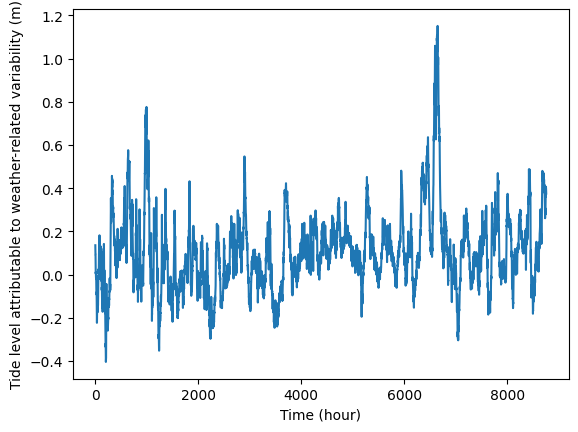

In [13]:
plt.plot(tide_variable)
plt.xlabel('Time (hour)')
plt.ylabel('Tide level attributable to weather-related variability (m)')


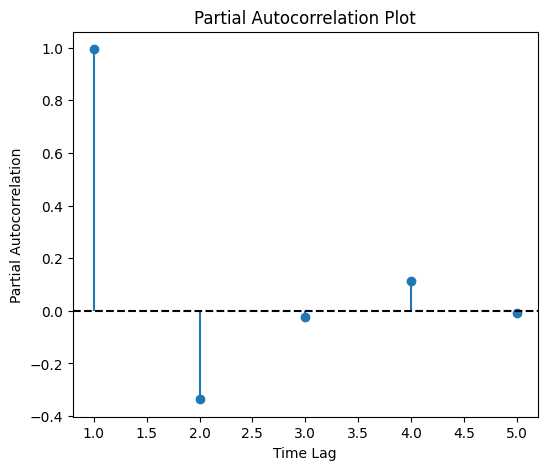

In [14]:
# Partial Autocorrelation
pacf_homogauss = pacf(tide_variable, nlags=5)

# Partial Autocorrelation Plot
plt.figure(figsize=(6, 5))
plt.stem(range(1, 6), pacf_homogauss[1:], markerfmt='o', basefmt=" ")
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Partial Autocorrelation")
plt.xlabel("Time Lag")
plt.title("Partial Autocorrelation Plot")
plt.show()

In [15]:
lb = [-0.99, 0.01]
ub = [0.99, 5]
init = [0.6, 0.3]

def ar1_loglik_whitened(theta, dat):
    # might need to include mean or trend parameters as well
    # subtract trend from data to make this mean-zero in this case
    rho, sigma = theta
    T = len(dat)
    ll = 0  # initialize log-likelihood counter
    for i in range(T):
        if i == 0:
            ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ll += norm.logpdf(dat[i], loc=rho * dat[i-1], scale=sigma)
    return ll


optim_whitened = minimize(lambda θ: -ar1_loglik_whitened(θ, tide_variable), init, bounds=list(zip(lb, ub)))
θ_wn_mle = np.round(optim_whitened.x, 2)
print("θ_wn_mle:", θ_wn_mle)


θ_wn_mle: [0.99 0.02]


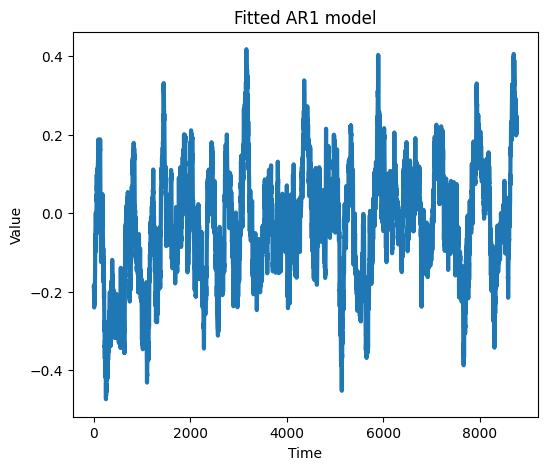

In [ ]:
# rho = 0.6
# sigma = 0.25
rho = optim_whitened.x[0]
sigma = optim_whitened.x[1]
T = 8760
ts_sim = np.zeros(T)


# simulate synthetic AR(1) series
for t in range(T):
    if t == 0:
        ts_sim[t] = np.random.normal(0, np.sqrt(sigma**2 / (1 - rho**2)))
    else:
        ts_sim[t] = np.random.normal(rho * ts_sim[t-1], sigma)

plt.figure(figsize=(6, 5))
plt.plot(np.arange(1, T+1), ts_sim, linewidth=3)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Fitted AR1 model")
plt.show()

In [17]:
num_realizations = 1000
max_levels = np.zeros(num_realizations)
for i in range(num_realizations):
    # simulate synthetic AR(1) series
    for t in range(T):
        if t == 0:
            ts_sim[t] = np.random.normal(0, np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ts_sim[t] = np.random.normal(rho * ts_sim[t-1], sigma)
    sim_tide_realization = gauge_data['Predicted (m)'] + ts_sim
    max_levels[i] = sim_tide_realization.max()

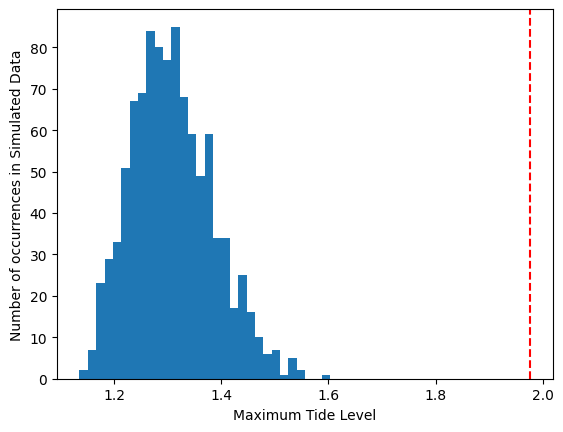

In [18]:
plt.hist(max_levels, bins=30)
plt.xlabel('Maximum Tide Level')
plt.ylabel('Number of occurrences in Simulated Data')
plt.axvline(x=gauge_data['Verified (m)'].max(), color='r', linestyle='--')

The observed maximum is unlikely to occur under the assumed distribution. This suggests that the assumptions behind the AR1 are likely inaccurate, as it is highly unlikely for the observed maximum to occur given these assumptions. An AR2 model may be a more accurate fit than AR1. Also, the tide level attributable to weather-related variability may not actually be normally distributed, as was assumed here, but might instead be distributed according to a fatter-tailed distribution, such as a cauchy distribution, thus allowing the more extreme high tide to occur.

## Problem 3

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

**In this problem**:

-   Load the data. You may need to standardize the predictors as they
    are much larger than the counts.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Plot the expected counts and 90% prediction intervals from your
    model. How well does the model predict the observed counts? In what
    ways does it do a good or bad job?
-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

# Solution

I load the dataset and normalize the columns. Then I develop a function salaman_model which takes the parameters and the data for the percentage of ground cover and salamander count, uses a link function, develops a poisson model, and calculates the log likelihood. I then minimize the negative of the log likelihood in order to fit the model parameters β_0 and β_1. I then take a series of values for percentage ground cover with around the same range as that of the data. For each of these, I compute lambda using the link function for the fitted model. I then draw 100,000 samples from a Poisson distribution with the value of lambda, and take the mean and the 5th and 95th percentile to define the 90% prediction interval, which I plot along with the data. In order to look at including forest age, I recreate the model with a link function which includes the forest age as another variable, with an additional parameter β_2.

In [19]:
data_dir = os.path.join("data", "salamanders.csv")
salamander_data = pd.read_csv(data_dir, index_col='SITE')

In [20]:
col = 'PCTCOVER'
salamander_data[col] = (salamander_data[col] - salamander_data[col].mean())/salamander_data[col].std()

col = 'FORESTAGE'
salamander_data[col] = (salamander_data[col] - salamander_data[col].mean())/salamander_data[col].std()

In [21]:
def salaman_model(params, pctcover, salaman_data):
    β_0, β_1 = params
    λ = np.exp(β_0 + β_1 * pctcover)
    loglik = np.sum(poisson.logpmf(salaman_data, λ))
    return loglik

In [22]:
lb = [-100.0, -100.0]
ub = [100.0, 100.0]
init = [0.0, 0.0]

result = minimize(lambda θ: -salaman_model(θ, salamander_data['PCTCOVER'], salamander_data['SALAMAN']), init, bounds=list(zip(lb, ub)))
θ_mle = result.x
print(np.round(θ_mle, decimals=5))

[0.42951 1.15951]


In [23]:
x = np.arange(salamander_data['PCTCOVER'].min(), salamander_data['PCTCOVER'].max(),0.01)

In [24]:
β_0 = θ_mle[0]
β_1 = θ_mle[1]
λ = np.exp(β_0 + β_1 * x)

In [25]:
percent_90 = np.zeros(len(λ))
lower_90 = np.zeros(len(λ))
means = np.zeros(len(λ))
for i in range(len(λ)):
    r = poisson.rvs(λ[i], size=100000)
    percent_90[i] = np.quantile(r,  0.95, axis=0)
    lower_90[i] = np.quantile(r,  0.05, axis=0)
    means[i] = np.quantile(r,  0.5, axis=0)

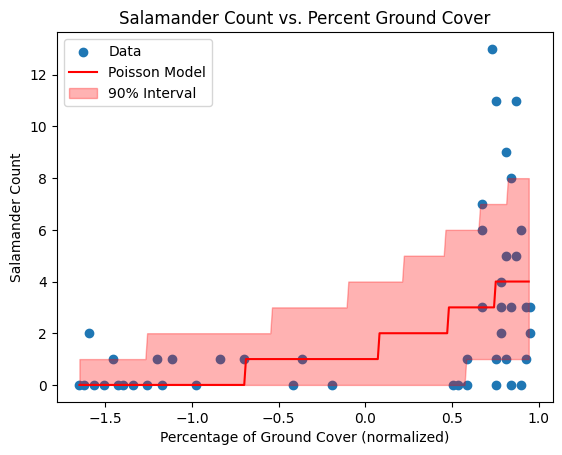

In [26]:
plt.scatter(salamander_data['PCTCOVER'], salamander_data['SALAMAN'])
# plt.plot(x, λ, color = 'orange')
plt.plot(x, means, color = 'red')
plt.fill_between(x, lower_90, percent_90, color='red', alpha=0.3, label = '90% Interval')
plt.ylabel("Salamander Count")
plt.xlabel("Percentage of Ground Cover (normalized)")
plt.title("Salamander Count vs. Percent Ground Cover")
plt.legend(['Data','Poisson Model','90% Interval' ])

In [27]:
def salaman_model(params, pctcover, forestage, salaman_data):
    β_0, β_1, β_2 = params
    λ = np.exp(β_0 + β_1 * pctcover + β_2 * forestage)
    loglik = np.sum(poisson.logpmf(salaman_data, λ))
    return loglik

In [28]:
lb = [-100.0, -100.0, -100.0]
ub = [100.0, 100.0, 100.0]
init = [0.0, 0.0, 0.0]

result = minimize(lambda θ: -salaman_model(θ, salamander_data['PCTCOVER'], salamander_data['FORESTAGE'], salamander_data['SALAMAN']), init, bounds=list(zip(lb, ub)))
θ_mle = result.x
print(np.round(θ_mle, decimals=5))

[ 0.42932  1.16247 -0.00409]


-   How well does the model predict the observed counts? In what
    ways does it do a good or bad job?

The model seems to do a decent job of indicating the overall trend. It does less well for high percentages of ground cover, for which there is a lot of variability in the data, with some counts of zero falling below the 90% prediction interval and other counts being fairly high, falling above this interval.


-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

The coefficient β_2 for forest age is very small at -0.00409, compared to 1.16247 for the percentage ground cover, less than 1% of the magnitude. This indicates that the variable has little impact on the model predictions, so including it in the model is unlikely to significantly improve its performance.

### Problem 4

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis.
While we won’t replicate the specific analysis in this paper, let’s use
the data to look at this hypothesis.

**In this problem**:

-   One might interpret the hypothesis to claim that the impact of the
    name is strengthened by the the more powerful. A measure of
    hurricane strength is its minimum pressure (`min_pressure` in the
    dataset). Fit a model that predicts deaths (‘deaths’) using the
    femininity of the name (`femininity`) and minimum pressure (you may
    need to standardize the pressure).
-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

# Solution

I standardize the pressure and femininity and fit a poisson model using a similar process to problem number 3. Then, I use the Poisson model to produce estimates for a range of pressures using the minimum and maximum values for feminity from the dataset. I plot these, along with the data points, with a different color for data points based on whether they are classified as female. I use this to examine the differences predicted by the model, and how well these align with the data.

In [29]:
data_dir = os.path.join("data", "Hurricanes.csv")
hurricane_data = pd.read_csv(data_dir)

In [30]:
col = 'min_pressure'
hurricane_data[col] = (hurricane_data[col] - hurricane_data[col].mean())/hurricane_data[col].std()

col = 'femininity'
hurricane_data[col] = (hurricane_data[col] - hurricane_data[col].mean())/hurricane_data[col].std()

In [31]:
def hurricane_model(params, pressure, fem, deaths):
    β_0, β_1, β_2 = params
    λ = np.exp(β_0 + β_1 * pressure + β_2 * fem)
    loglik = np.sum(poisson.logpmf(deaths, λ))
    return loglik

In [32]:
lb = [-10.0, -50.0, -10.0]
ub = [10.0, 50.0, 10.0]
init = [5.0, 0.0, 5.0]

result = minimize(lambda params: -hurricane_model(params, hurricane_data['min_pressure'].astype('float'), hurricane_data['femininity'].astype('float'), hurricane_data['deaths'].astype('float')), init, bounds=list(zip(lb, ub)))
θ_mle = result.x
print(np.round(θ_mle, decimals=5))

[ 2.73686 -0.71528  0.20728]


In [33]:
pressures = np.arange(hurricane_data['min_pressure'].min(), hurricane_data['min_pressure'].max(),0.01)

In [34]:
β_0 = result.x[0]
β_1 = result.x[1]
β_2 = result.x[2]
λ_masc = np.exp(β_0 + β_1 * pressures + β_2 * hurricane_data['femininity'].min())
λ_fem = np.exp(β_0 + β_1 * pressures + β_2 * hurricane_data['femininity'].max())

In [35]:
percent_90_m = np.zeros(len(λ_masc))
lower_90_m = np.zeros(len(λ_masc))
means_m = np.zeros(len(λ_masc))
for i in range(len(λ_masc)):
    r = poisson.rvs(λ_masc[i], size=100000)
    percent_90_m[i] = np.quantile(r,  0.95, axis=0)
    lower_90_m[i] = np.quantile(r,  0.05, axis=0)
    means_m[i] = np.quantile(r,  0.5, axis=0)

In [36]:
percent_90_f = np.zeros(len(λ_fem))
lower_90_f = np.zeros(len(λ_fem))
means_f = np.zeros(len(λ_fem))
for i in range(len(λ_fem)):
    r = poisson.rvs(λ_fem[i], size=100000)
    percent_90_f[i] = np.quantile(r,  0.95, axis=0)
    lower_90_f[i] = np.quantile(r,  0.05, axis=0)
    means_f[i] = np.quantile(r,  0.5, axis=0)

In [37]:
hurricanes_fem = hurricane_data[hurricane_data['female'] == 1]
hurricanes_mas = hurricane_data[hurricane_data['female'] == 0]

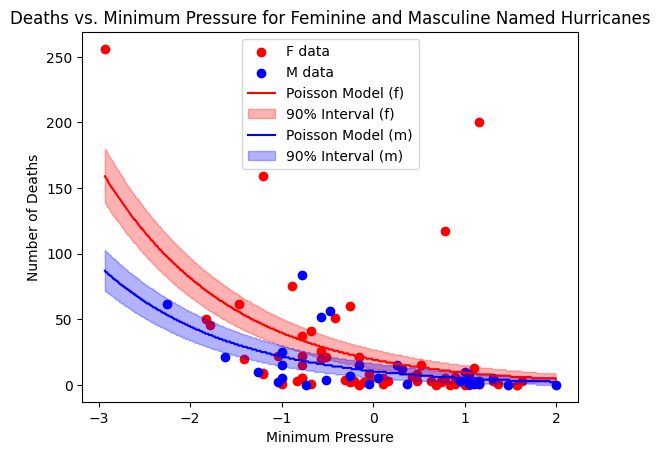

In [38]:
plt.scatter(hurricanes_fem['min_pressure'], hurricanes_fem['deaths'], color = 'red')
plt.scatter(hurricanes_mas['min_pressure'], hurricanes_mas['deaths'], color = 'blue')
# plt.plot(x, λ, color = 'orange')


plt.plot(pressures, means_f, color = 'red')
plt.fill_between(pressures, lower_90_f, percent_90_f, color='red', alpha=0.3, label = '90% Interval')

plt.plot(pressures, means_m, color = 'blue')
plt.fill_between(pressures, lower_90_m, percent_90_m, color='blue', alpha=0.3, label = '90% Interval')

plt.ylabel("Number of Deaths")
plt.xlabel("Minimum Pressure")
plt.title("Deaths vs. Minimum Pressure for Feminine and Masculine Named Hurricanes")
plt.legend(['F data', 'M data', 'Poisson Model (f)','90% Interval (f)','Poisson Model (m)','90% Interval (m)' ])
# 'Data',

-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
    
The model performs best for higher minimum pressures, where there is least variability in the data. For lower pressures there is more variability, with both larger and small numbers of deaths, making it more challenging for the model to predict. For lower minimum pressures, the feminine model does appear to predict higher deaths. However, the effect size of gender of the name does not seem plausible given that for most of the range both masculine and feminine data points appear throughout.

-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

This analysis does not provide clear evidence of a significant impact of gender of a hurricane’s name on deaths. While the model does predict some difference, particularly for lower minimum pressures, with the 90th intervals for the most masculine and feminine names being separate from each other, there are feminine data points throughout the range, and masculine data points throughout most of the range, indicating that much of the data is random rather than being clearly correlated with gender. There are four outlier data points with a particularly large number of deaths which are all feminine. However, this could be due to coincidence, and could be skewing the data. One possible approach could be to remove these data points and see whether gender still appears to have an impact. If the hypothesis was correct, we would expect to see an impact throughout the range, not just for the deadliest few hurricanes.


## References

https://www.codeconvert.ai/julia-to-python-converter

https://www.pnas.org/doi/10.1073/pnas.0907765106

https://support.climateinteractive.org/support/solutions/articles/47001197685-what-does-the-long-term-equilibrium-sea-level-rise-slr-map-mean-